# Active Brownian Particle (ABP) in a 2D Harmonic Trap

We consider an overdamped Active Brownian Particle (ABP) in two dimensions.

The particle position is

$\mathbf r=(x,y)$

and its orientation is

$\theta.$

The governing Langevin equations are

$\dot x=-\beta x + v_0 \cos\theta + \sqrt{2D_t}\,\eta_x(t)$

$\dot y = -\beta y + v_0 \sin\theta + \sqrt{2D_t}\,\eta_y(t)$

$\dot\theta = \sqrt{2D_r}\,\eta_\theta(t)$

where

- \(v_0\) : self-propulsion speed
- \(D_t\) : translational diffusion coefficient
- \(D_r\) : rotational diffusion coefficient
- \(\beta\) : harmonic trap strength

The harmonic potential is

$ U(x,y) = \frac{\beta}{2}(x^2+y^2)$

which generates the restoring force

$\mathbf F=-\nabla U=(-\beta x,-\beta y).$

We solve these equations using the Euler-Maruyama method.

# Single Particle

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7,7)
plt.rcParams["font.size"] = 14

# --------------------------
# Physical parameters
# --------------------------

v0 = 1.0          # self-propulsion speed
beta = 1.0        # trap strength

Dt = 1.0          # translational diffusion
Dr = 0.1          # rotational diffusion

# --------------------------
# Numerical parameters
# --------------------------

T = 100.0         # total simulation time
dt = 1e-3         # timestep

N = int(T/dt)

print("Number of timesteps =", N)

# --------------------------
# Allocate arrays
# --------------------------
x = np.zeros(N+1)
y = np.zeros(N+1)
theta = np.zeros(N+1)

# --------------------------
# Initial Conditions
# --------------------------
x = np.zeros(N+1)
y = np.zeros(N+1)
theta = np.zeros(N+1)

x[0] = 0.0
y[0] = 0.0
theta[0] = 0.0

Number of timesteps = 100000


## Euler–Maruyama Integrator

The stochastic differential equations (SDEs) governing the motion of an Active Brownian Particle (ABP) in a two-dimensional harmonic trap are

$dx = \left(-\beta x + v_0 \cos\theta\right)dt +\sqrt{2D_t}\, dW_x ,$

$dy = \left(-\beta y + v_0 \sin\theta \right)dt + \sqrt{2D_t}\, dW_y , $

$ d\theta = \sqrt{2D_r}\, dW_\theta , $

where

* $v_0$ is the self-propulsion speed,
* $\beta$ is the harmonic trap strength,
* $D_t$ is the translational diffusion coefficient,
* $D_r$ is the rotational diffusion coefficient,
* $W_x$, $W_y$, and $W_\theta$ are independent Wiener processes.

---

## Euler–Maruyama Discretization

For a timestep $\Delta t$, the Wiener increments satisfy

$ dW \approx \sqrt{\Delta t}\, \xi ,$

where $\xi \sim \mathcal N(0,1)$ is a standard Gaussian random variable.

Applying the Euler–Maruyama scheme gives

$ \theta_{n+1} = \theta_n + \sqrt{2D_r\Delta t}\, \xi_\theta , $

$x_{n+1} =  x_n + \left(-\beta x_n + v_0 \cos\theta_n \right)\Delta t + \sqrt{2D_t\Delta t}\, \xi_x , $

$ y_{n+1} = y_n + \left(-\beta y_n+ v_0 \sin\theta_n\right)\Delta t + \sqrt{2D_t\Delta t},\xi_y.$

At each timestep:

1. Generate three independent Gaussian random numbers

$ \xi_x,;\xi_y,;\xi_\theta\sim \mathcal N(0,1).
$

2. Update the orientation $\theta$.

3. Compute the active propulsion direction

$\mathbf e(\theta) = (\cos\theta,\sin\theta).$

4. Update the particle position using the deterministic drift and stochastic diffusion terms.

### Numerical Implementation


In [19]:
for n in range(N):

    xi_x = np.random.randn()
    xi_y = np.random.randn()
    xi_theta = np.random.randn()

    theta[n+1] = (
        theta[n]
        + np.sqrt(2*Dr*dt)*xi_theta
    )

    x[n+1] = (
        x[n]
        + (-beta*x[n] + v0*np.cos(theta[n]))*dt
        + np.sqrt(2*Dt*dt)*xi_x
    )

    y[n+1] = (
        y[n]
        + (-beta*y[n] + v0*np.sin(theta[n]))*dt
        + np.sqrt(2*Dt*dt)*xi_y
    )

This implementation directly follows the stochastic Langevin equations and is the standard numerical method used in simulations of Active Brownian Particles.


## Plot Trajectory

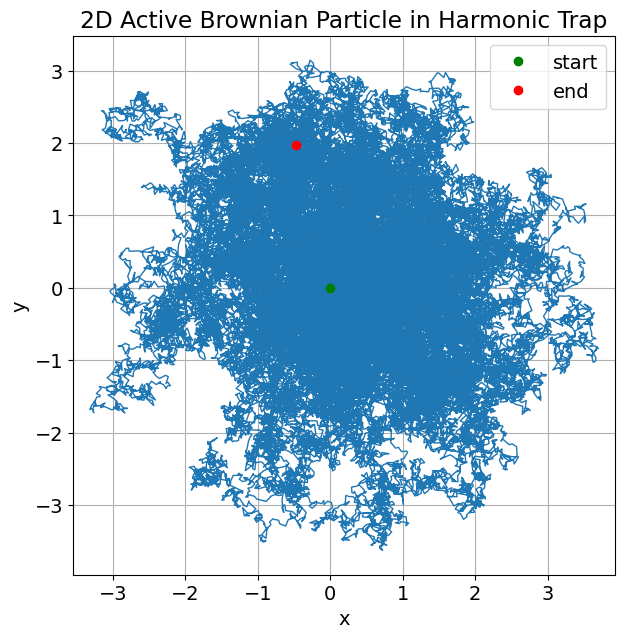

In [20]:
plt.figure()

plt.plot(x,y,lw=1)

plt.plot(x[0],y[0],'go',label='start')
plt.plot(x[-1],y[-1],'ro',label='end')

plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Active Brownian Particle in Harmonic Trap")

plt.axis("equal")
plt.grid()
plt.legend()

plt.show()

### Orientation Dynamics

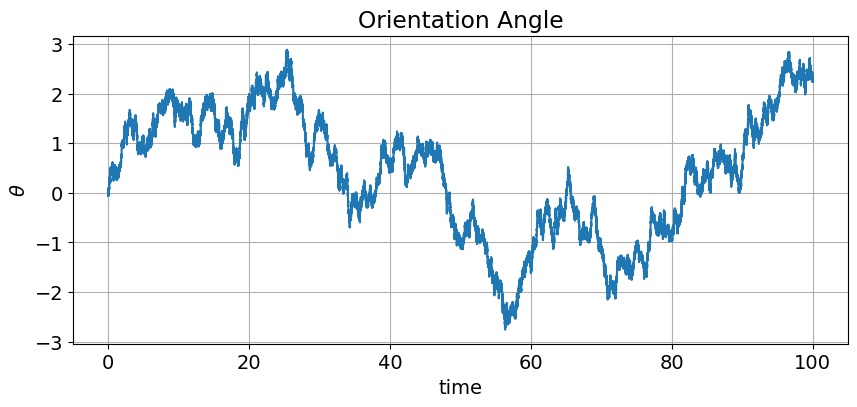

In [21]:
time = np.arange(N+1)*dt

plt.figure(figsize=(10,4))

plt.plot(time,theta)

plt.xlabel("time")
plt.ylabel(r"$\theta$")
plt.title("Orientation Angle")

plt.grid()

plt.show()

The trap competes with activity.

Define

$r(t)=x^2+y^2$.

A rough force balance gives

$\beta r \approx v_0$


or

$r^* \approx v_0/\beta$

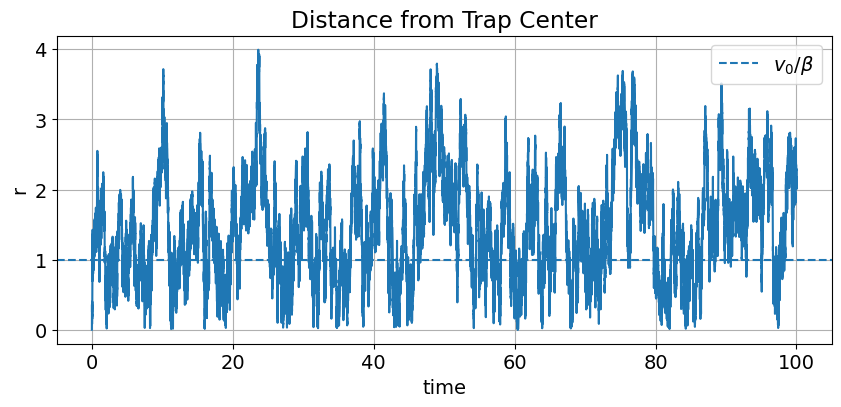

In [22]:
r = np.sqrt(x**2+y**2)

plt.figure(figsize=(10,4))

plt.plot(time,r)

plt.axhline(v0/beta,
            ls='--',
            label=r'$v_0/\beta$')

plt.xlabel("time")
plt.ylabel("r")

plt.title("Distance from Trap Center")

plt.legend()
plt.grid()

plt.show()

## Mean Squared Displacement (Single Trajectory)

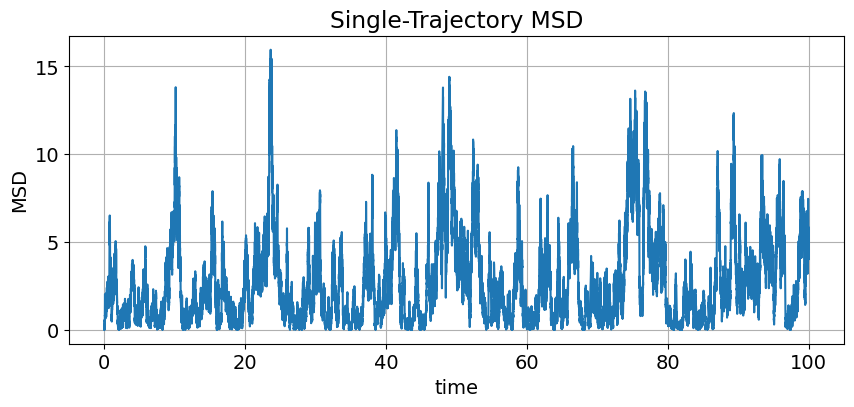

In [23]:
msd = (x-x[0])**2 + (y-y[0])**2

plt.figure(figsize=(10,4))

plt.plot(time,msd)

plt.xlabel("time")
plt.ylabel("MSD")

plt.title("Single-Trajectory MSD")

plt.grid()

plt.show()

## Phase-Space View

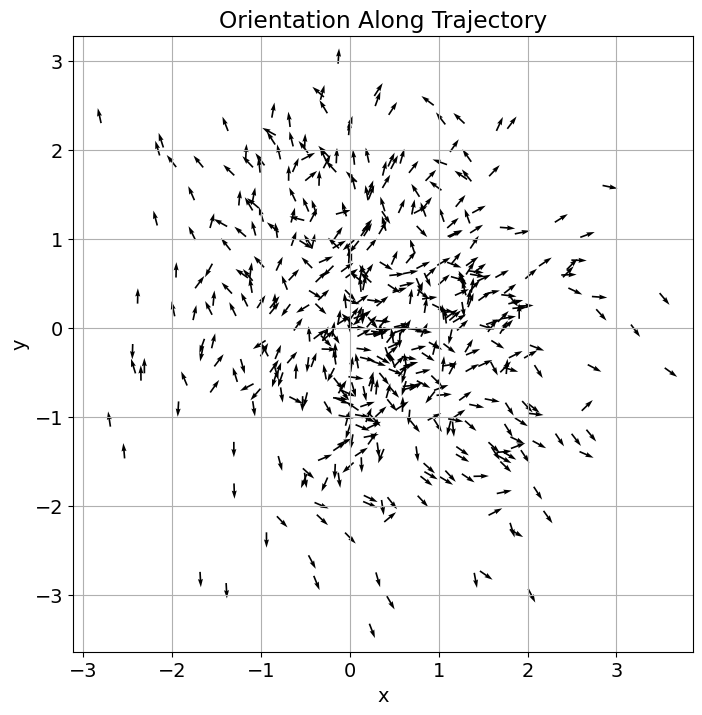

In [24]:
plt.figure(figsize=(8,8))

plt.quiver(
    x[::200],
    y[::200],
    np.cos(theta[::200]),
    np.sin(theta[::200])
)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orientation Along Trajectory")

plt.axis("equal")
plt.grid()

plt.show()

# Ensemble of particles

In [25]:
n_particles = 1000

x = np.zeros((N+1, n_particles))
y = np.zeros((N+1, n_particles))
theta = np.zeros((N+1, n_particles))


for n in range(N):

    xi_x = np.random.randn(n_particles)
    xi_y = np.random.randn(n_particles)
    xi_theta = np.random.randn(n_particles)

    theta[n+1] = (
        theta[n]
        + np.sqrt(2*Dr*dt)*xi_theta
    )

    x[n+1] = (
        x[n]
        + (-beta*x[n] + v0*np.cos(theta[n]))*dt
        + np.sqrt(2*Dt*dt)*xi_x
    )

    y[n+1] = (
        y[n]
        + (-beta*y[n] + v0*np.sin(theta[n]))*dt
        + np.sqrt(2*Dt*dt)*xi_y
    )

## Plot

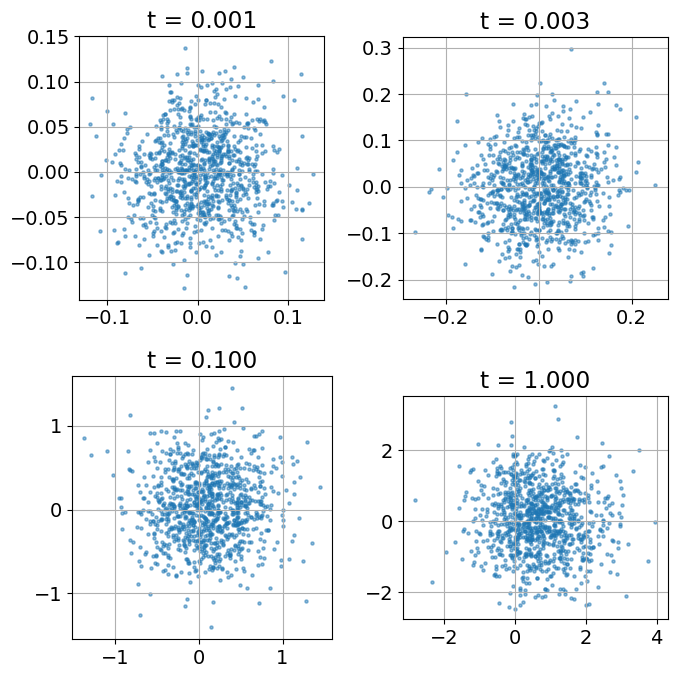

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(7,7))

snapshot_indices = [1, 3, 100, 1000]

for ax, idx in zip(axs.flat, snapshot_indices):

    ax.scatter(
        x[idx,:],
        y[idx,:],
        s=5,
        alpha=0.5
    )

    ax.set_title(f't = {idx*dt:.3f}')
    ax.set_aspect('equal')
    ax.grid(True)

plt.tight_layout()
plt.show()

## Radial Distribution of Active Brownian Particles

At the final simulation time (t=T), each particle occupies a position

$(x_i,y_i)$.

The distance of particle (i) from the trap center is

$r_i = \sqrt{x_i^2+y_i^2}$.

The collection of all (r_i) values provides information about the steady-state spatial distribution of the active particles.

For a passive Brownian particle in a harmonic trap, the radial distribution is expected to follow the Boltzmann distribution

$P(r) \propto r\, \exp\left(-\frac{\beta r^2}{2D_t}\right),$

which is peaked at the origin.

For an Active Brownian Particle (ABP), self-propulsion competes with the restoring force of the trap. When the activity is sufficiently strong, particles preferentially accumulate away from the center, producing a ring-like distribution. A simple force-balance argument predicts the characteristic radius

$r^* \approx \frac{v_0}{\beta},$

obtained by balancing the active force with the harmonic restoring force,

$v_0 \sim \beta r$.

The histogram below estimates the steady-state radial probability density (P(r)) from the ensemble of particles. The kernel density estimate (KDE) provides a smooth approximation to the underlying distribution.


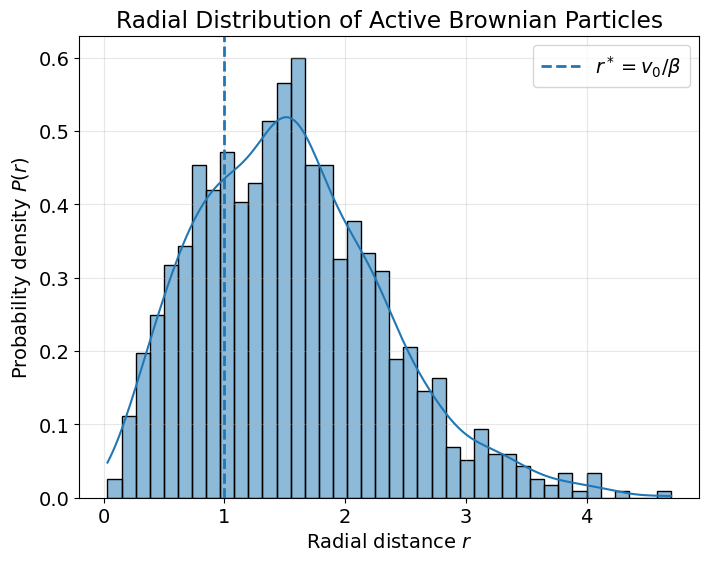

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------
# Radial distance at final time
# ------------------------------------

r = np.sqrt(x[N,:]**2 + y[N,:]**2)

# Store in dataframe
df_dynamics = pd.DataFrame({
    "x": x[N,:],
    "y": y[N,:],
    "r": r
})

# ------------------------------------
# Plot histogram + KDE
# ------------------------------------

plt.figure(figsize=(8,6))

sns.histplot(
    data=df_dynamics,
    x="r",
    stat="density",
    bins=40,
    kde=True
)

# theoretical active radius
plt.axvline(
    v0/beta,
    linestyle="--",
    linewidth=2,
    label=r"$r^* = v_0/\beta$"
)

plt.xlabel(r"Radial distance $r$")
plt.ylabel(r"Probability density $P(r)$")
plt.title("Radial Distribution of Active Brownian Particles")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Comparison with the Passive Brownian Particle

To assess the effect of activity, it is useful to compare the simulated Active Brownian Particle (ABP) distribution with the corresponding passive Brownian particle confined in the same harmonic trap.

When the propulsion speed is set to zero,

$$
v_0 = 0,
$$

the equations of motion reduce to the two-dimensional Ornstein–Uhlenbeck process

$$ \dot{x}= -\beta x + \sqrt{2D_t} \eta_x(t), $$

$$
\dot{y} = -\beta y + \sqrt{2D_t} \eta_y(t).
$$

The stationary probability distribution is the Boltzmann distribution

$$ P(x,y) = \frac{\beta}{2\pi D_t} \exp\left(-\frac{\beta(x^2+y^2)}{2D_t}\right).$$

Expressed in polar coordinates, the radial probability density becomes

$$
P(r) = \frac{\beta}{D_t}r \exp\left(-\frac{\beta r^2}{2D_t}\right),
$$

which is a Rayleigh distribution.

The mean radial distance can be computed analytically:

$$\langle r\rangle_{\rm passive} = \int_0^\infty r\,P(r)\,dr
\sqrt{\frac{\pi D_t}{2\beta}}.$$

For the parameters used in this simulation,

$$
D_t = 1,
\qquad
\beta = 1,
$$

the passive theory predicts

$$
\langle r\rangle_{\rm passive}
=
\sqrt{\frac{\pi}{2}}
\approx 1.253.
$$

The active simulation yields a larger mean radius because self-propulsion continuously drives particles away from the trap center. Comparing the measured value

$$
\langle r\rangle_{\rm active}
$$

with the passive prediction provides a quantitative measure of the influence of activity on the stationary particle distribution.

A useful quantity is the relative increase in mean radius,

$$
\frac{
\langle r\rangle_{\rm active}
-
\langle r\rangle_{\rm passive}
}
{
\langle r\rangle_{\rm passive}
}
\times 100%,
$$

which measures how strongly active motion expands the spatial distribution compared with thermal fluctuations alone.


In [29]:
# Passive-theory prediction
r_passive = np.sqrt(np.pi * Dt / (2 * beta))

# Active simulation result
r_active = np.mean(r)

print(f"Mean radius (active simulation) = {r_active:.4f}")
print(f"Mean radius (passive theory)    = {r_passive:.4f}")

increase = 100 * (r_active - r_passive) / r_passive

print(f"Relative increase due to activity = {increase:.2f}%")

Mean radius (active simulation) = 1.5583
Mean radius (passive theory)    = 1.2533
Relative increase due to activity = 24.33%
